
# 08 — Rapidly build models with Random Forest

In this notebook, you'll see how **Random Forests** improve on single Decision Trees by combining the predictions of many trees trained on slightly different data.  

You'll use the same `make_moons` dataset to compare performance and visualize smoother decision boundaries.


## Import libraries

In [1]:

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons

## Generate the dataset

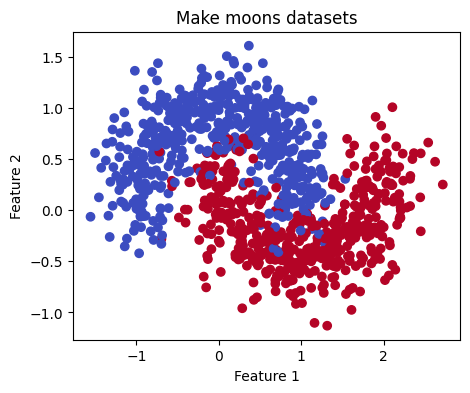

In [2]:
X, y = make_moons(n_samples=1000, noise=0.25, random_state=42)

plt.figure(figsize=(5,4))
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.coolwarm)
plt.title("Make moons datasets")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## Train a Random Forest model

In [5]:
from numpy.random import RandomState
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

forest = RandomForestClassifier(n_estimators=50, random_state=1)
forest.fit(X_train, y_train)


RandomForestClassifier(n_estimators=50, random_state=1)

In [6]:
from sklearn.metrics import accuracy_score
predictions = forest.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"Accuracy = {accuracy}")

Accuracy = 0.9533333333333334


## Examine feature importances

,0
Feature 1,0.450265
Feature 2,0.549735


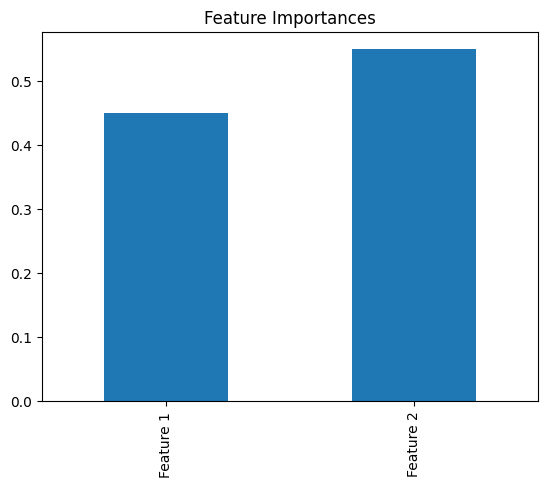

In [11]:
import pandas as pd
features_importances = pd.Series(forest.feature_importances_, index=["Feature 1", "Feature 2"])
features_importances.plot(kind="bar", title="Feature Importances")

features_importances

In [12]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, max_depth=4, random_state=1)
gb.fit(X_train, y_train)

gb_predictions = gb.predict(X_test)

gb_accuracy = accuracy_score(y_test, gb_predictions)

print(f"Gradient Boosting Accuracy = {gb_accuracy}")

Gradient Boosting Accuracy = 0.9566666666666667


In [13]:
import lightgbm as lgb

lgbm = lgb.LGBMClassifier(n_estimators=50, max_depth=4, learning_rate=0.1, random_state=1)
lgbm.fit(X_train, y_train)

lgbm_predictions = lgbm.predict(X_test)
lgbm_accuracy = accuracy_score(y_test, lgbm_predictions)

print(f"Light Gradient Boosting Machine Accuracy = {lgbm_accuracy}")


[LightGBM] [Info] Number of positive: 356, number of negative: 344
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000498 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 467
[LightGBM] [Info] Number of data points in the train set: 700, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.508571 -> initscore=0.034289
[LightGBM] [Info] Start training from score 0.034289
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [14]:
def plot_decision_boundary(model, X, y, ax, title):
    h = .02
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.6)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolor='k')
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

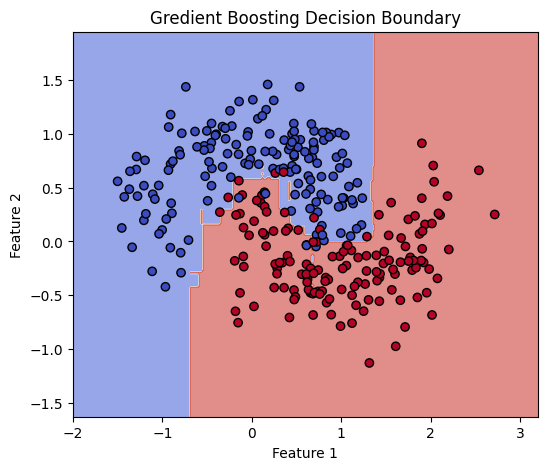

In [16]:
fig, ax = plt.subplots(figsize=(6,5))
plot_decision_boundary(gb, X_test, y_test, ax, "Gredient Boosting Decision Boundary")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


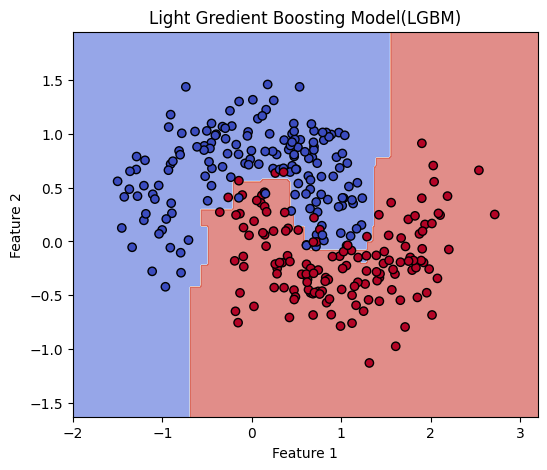

In [17]:
fig, ax = plt.subplots(figsize=(6,5))
plot_decision_boundary(lgbm, X_test, y_test, ax, "Light Gredient Boosting Model(LGBM)")
plt.show()